In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
words = open('names.txt', 'r').read().splitlines()

In [3]:
chars = sorted(list(set(''.join(words))))
stoi = { s:i+1 for i,s in enumerate(chars) }
stoi['.'] = 0
itos = { i:s for s,i in stoi.items() }
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [4]:
block_size = 3

def build_data(words):
    X, Y = [], []

    for w in words:
        context = block_size * [0]
        for ch in w + '.':
            X.append(context)
            ix = stoi[ch]
            Y.append(ix)
            context = context[1:] + [ix]

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    
    print(X.shape, Y.shape)
    return (X, Y)

import random
random.seed(42)
random.shuffle(words)

n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr, Ytr = build_data(words[:n1])
Xdev, Ydev = build_data(words[n1:n2])
Xte, Yte = build_data(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [5]:
n_embd = 10
n_hidden = 200

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, n_embd), generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g)
b1 = torch.randn((n_hidden), generator=g)
W2 = torch.randn((n_hidden, 27), generator=g)
b2 = torch.randn((27), generator=g)

parameters = [C, W1, b1, W2, b2]

for p in parameters:
    p.requires_grad = True

In [6]:
epoch = 300000
batch_size = 32
lossi = []

for i in range(epoch):
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)

    emb = C[Xtr[ix]]
    h = torch.tanh(emb.view(-1, n_embd * block_size) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Ytr[ix])

    for p in parameters:
        p.grad = None
    loss.backward()

    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    lossi.append(loss.item())

    if i % 10000 == 0:
        print(f'steps: {i:7d}/{epoch:7d} loss: {loss.item():.4f}')

steps:       0/ 300000 loss: 27.8817
steps:   10000/ 300000 loss: 2.9578
steps:   20000/ 300000 loss: 2.5038
steps:   30000/ 300000 loss: 2.7977
steps:   40000/ 300000 loss: 2.0222
steps:   50000/ 300000 loss: 2.4531
steps:   60000/ 300000 loss: 2.4698
steps:   70000/ 300000 loss: 2.1608
steps:   80000/ 300000 loss: 2.3721
steps:   90000/ 300000 loss: 2.3569
steps:  100000/ 300000 loss: 2.0654
steps:  110000/ 300000 loss: 2.3605
steps:  120000/ 300000 loss: 1.9112
steps:  130000/ 300000 loss: 2.3954
steps:  140000/ 300000 loss: 2.2651
steps:  150000/ 300000 loss: 2.1218
steps:  160000/ 300000 loss: 2.0267
steps:  170000/ 300000 loss: 1.7762
steps:  180000/ 300000 loss: 2.0269
steps:  190000/ 300000 loss: 1.8401
steps:  200000/ 300000 loss: 2.2940
steps:  210000/ 300000 loss: 1.7752
steps:  220000/ 300000 loss: 2.4566
steps:  230000/ 300000 loss: 2.5287
steps:  240000/ 300000 loss: 2.2843
steps:  250000/ 300000 loss: 2.2953
steps:  260000/ 300000 loss: 2.1494
steps:  270000/ 300000 loss

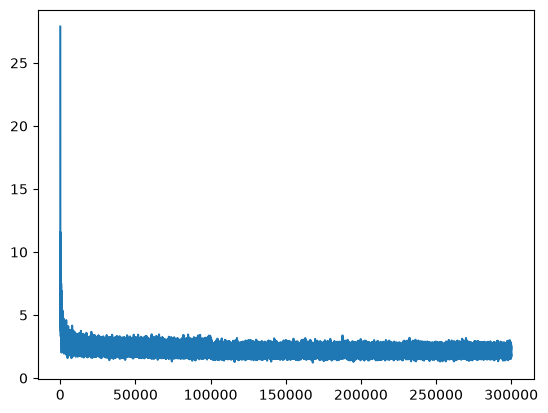

In [7]:
plt.plot(lossi)

In [8]:
emb = C[Xtr]
h = torch.tanh(emb.view(-1, block_size * n_embd) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ytr)
print(f'{loss=}')

loss=tensor(2.1183, grad_fn=<NllLossBackward0>)


In [9]:
emb = C[Xdev]
h = torch.tanh(emb.view(-1, block_size * n_embd) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ydev)
print(f'{loss=}')

loss=tensor(2.1617, grad_fn=<NllLossBackward0>)
